In [2]:
import pandas as pd

In [4]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Fetch MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X, y = mnist["data"], mnist["target"].astype(int)
print("Original dataset shape:", X.shape, y.shape)

Original dataset shape: (70000, 784) (70000,)


In [7]:
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

print("Filtered dataset shape:", X.shape, y.shape)

Filtered dataset shape: (14780, 784) (14780,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = log_reg.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9993234100135318

Confusion Matrix:
 [[1401    1]
 [   1 1553]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1402
           1       1.00      1.00      1.00      1554

    accuracy                           1.00      2956
   macro avg       1.00      1.00      1.00      2956
weighted avg       1.00      1.00      1.00      2956



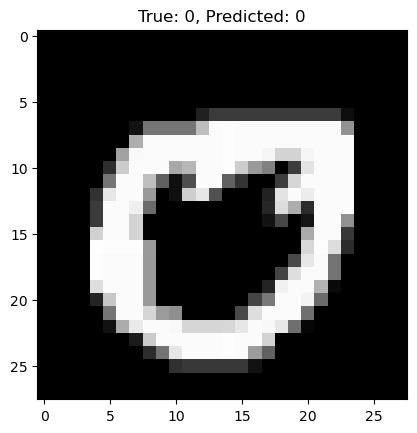

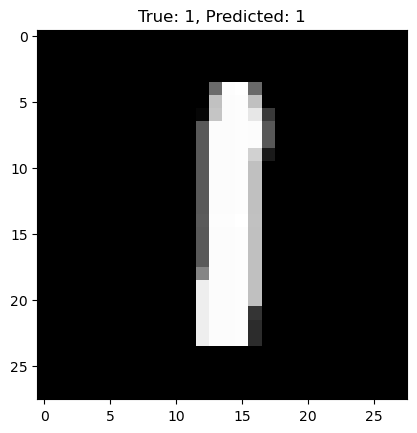

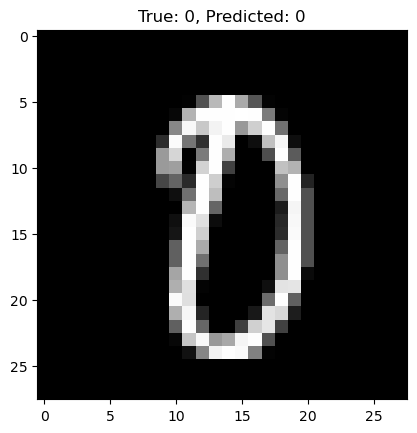

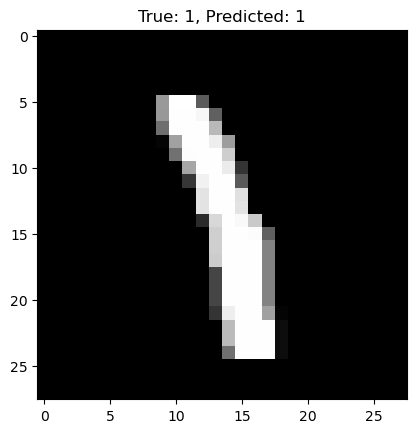

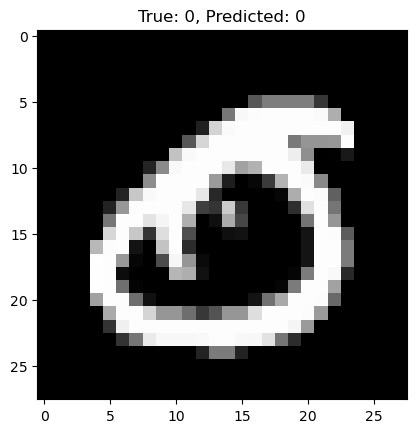

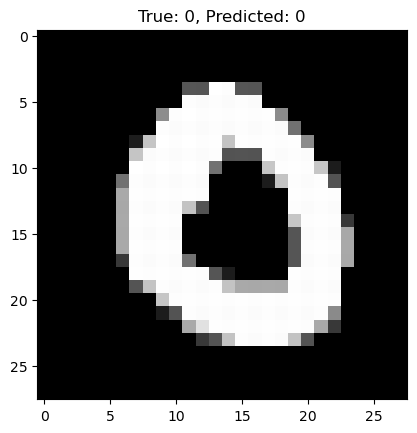

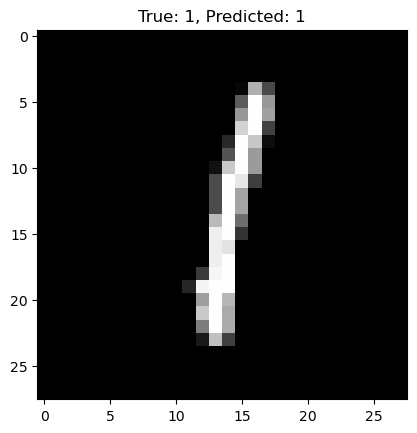

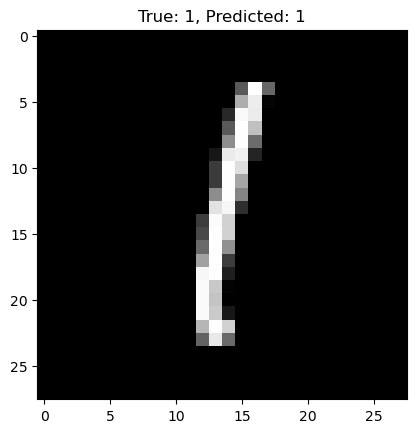

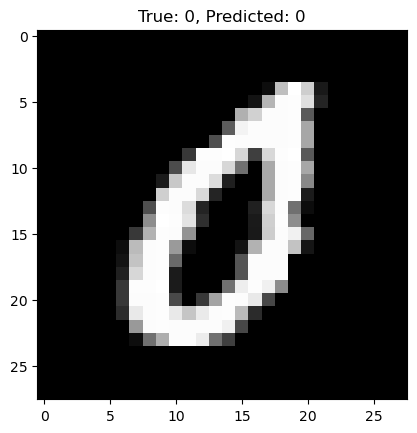

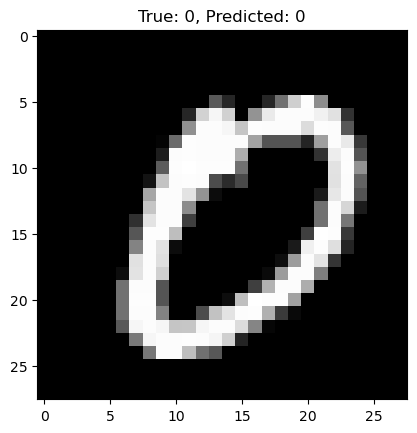

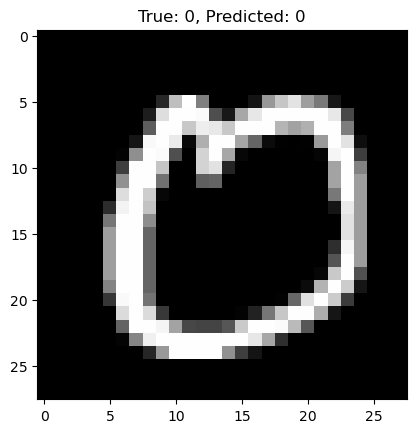

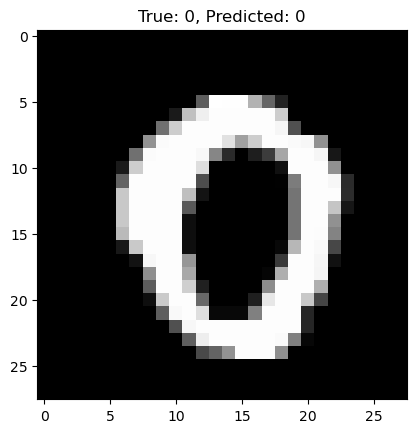

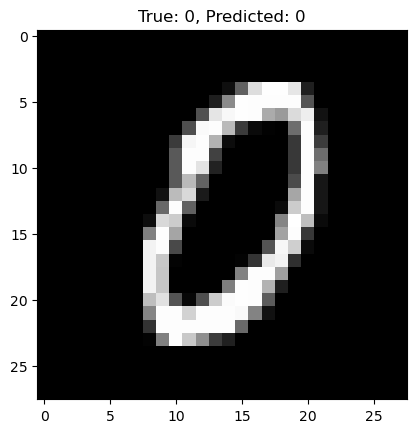

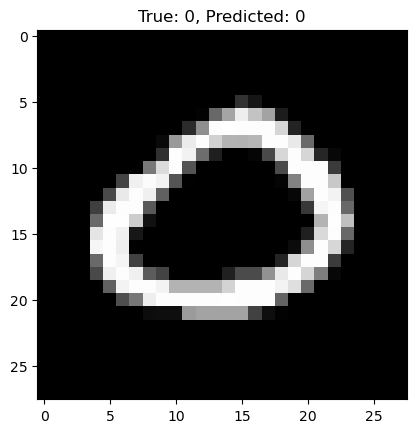

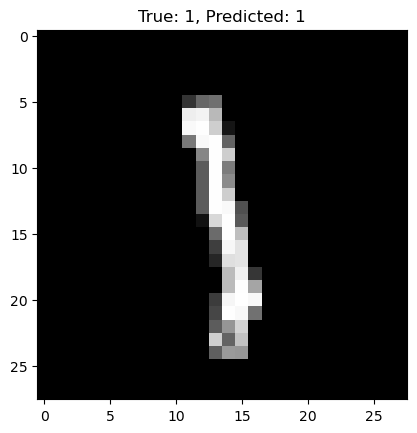

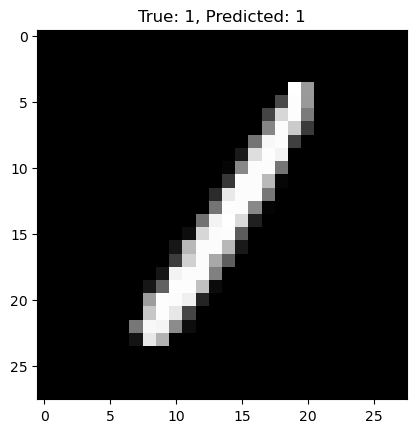

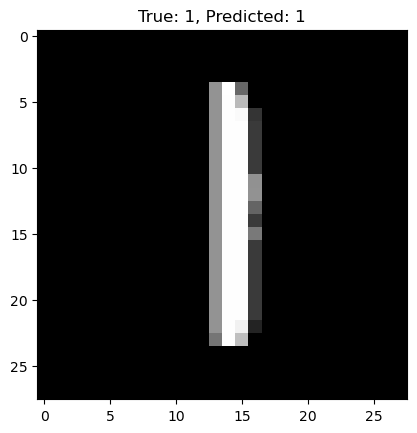

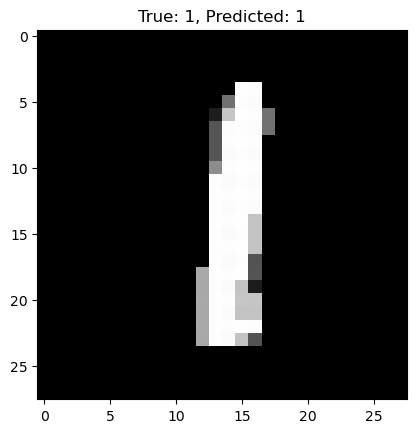

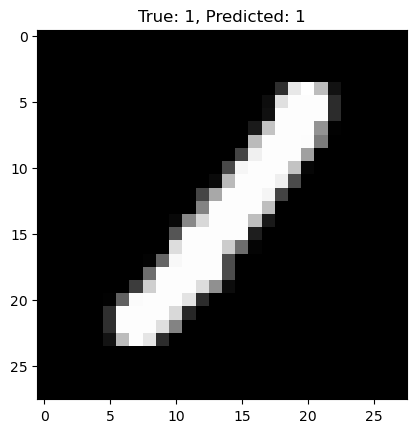

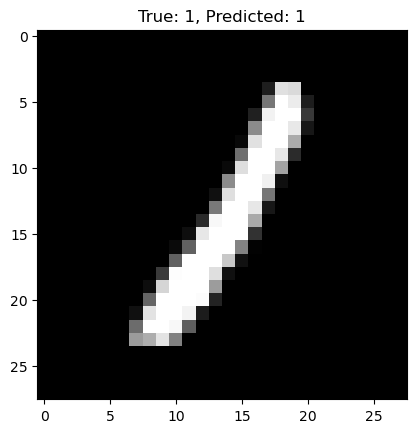

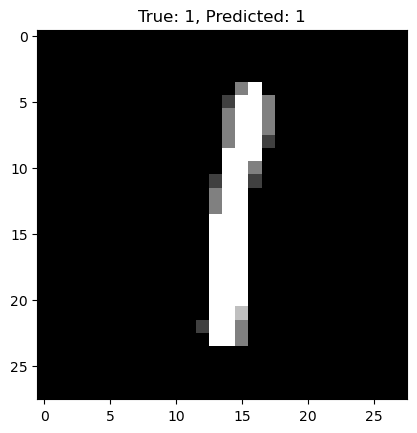

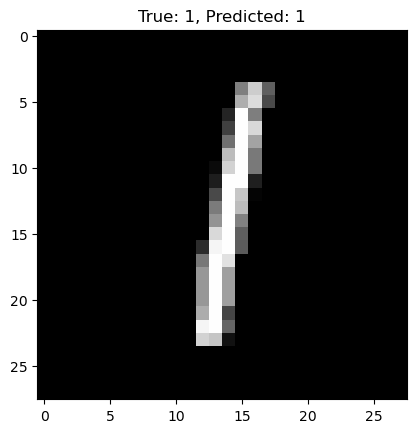

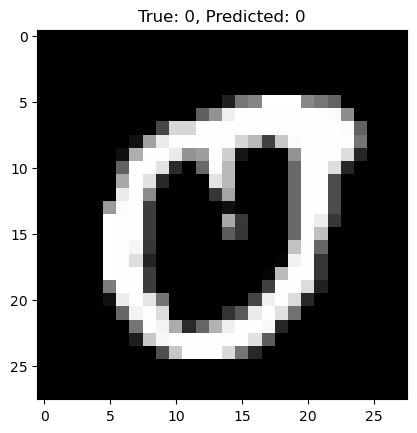

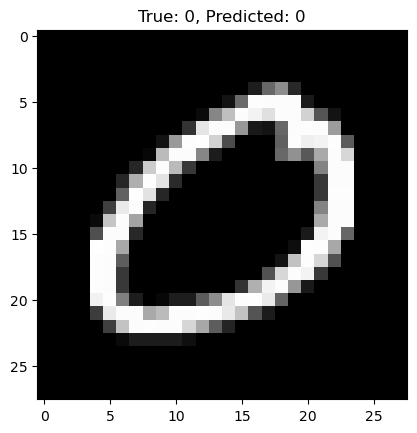

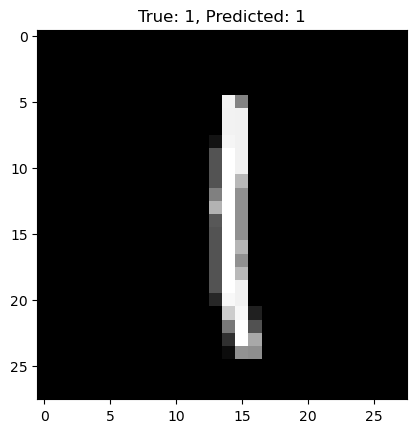

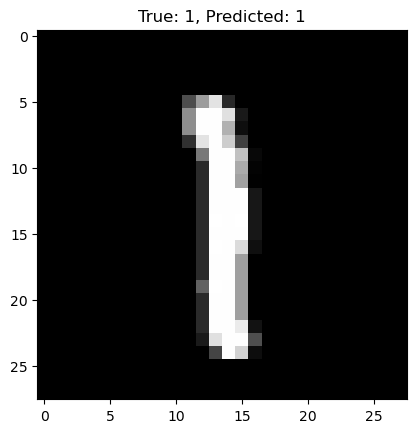

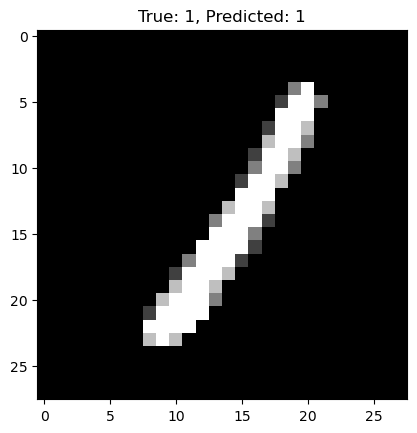

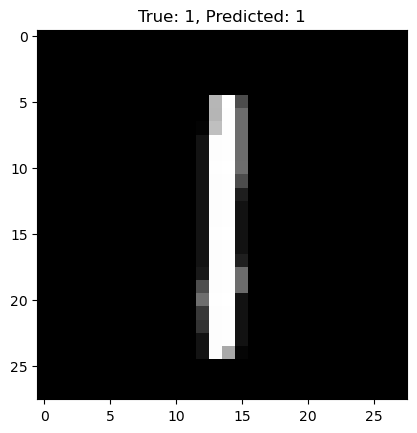

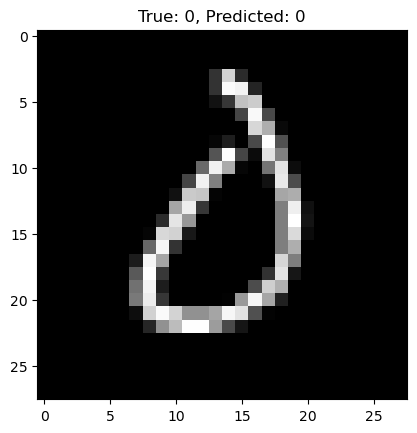

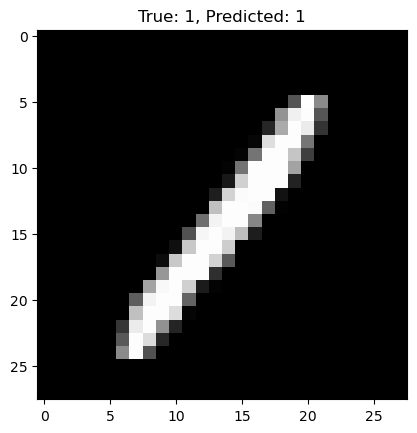

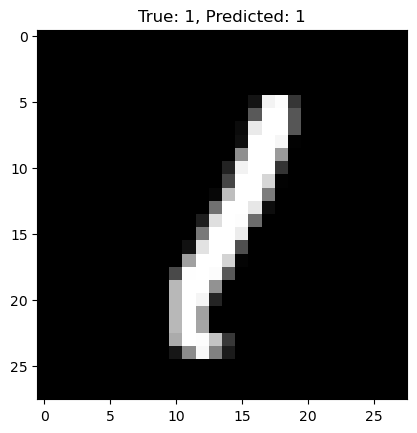

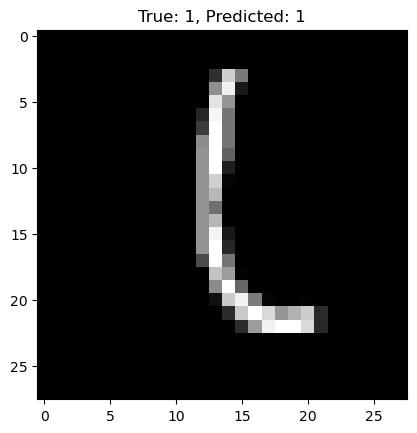

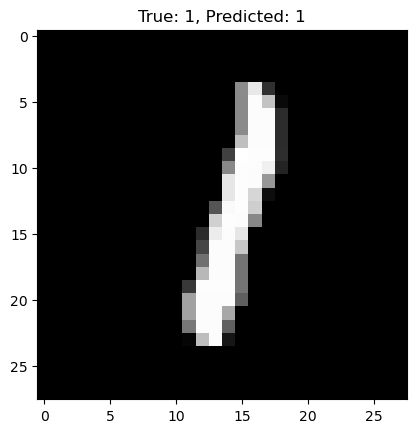

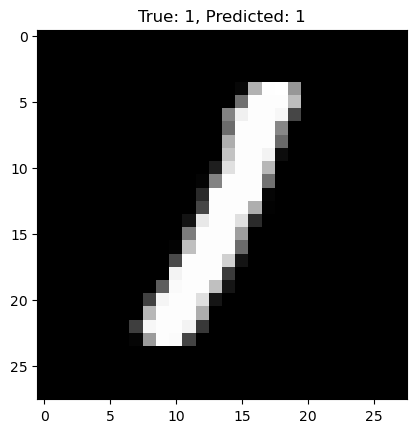

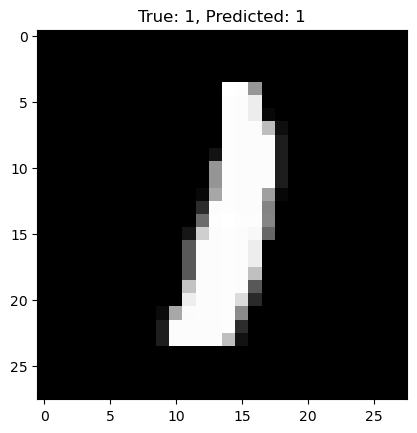

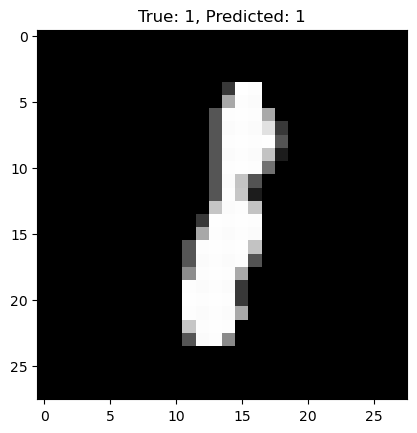

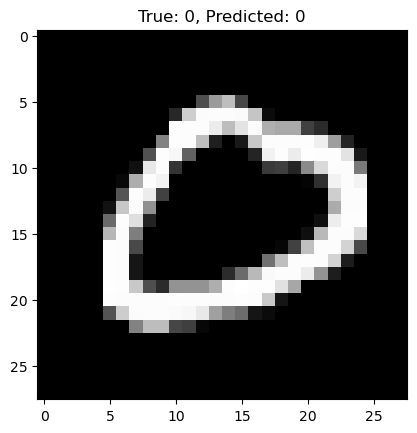

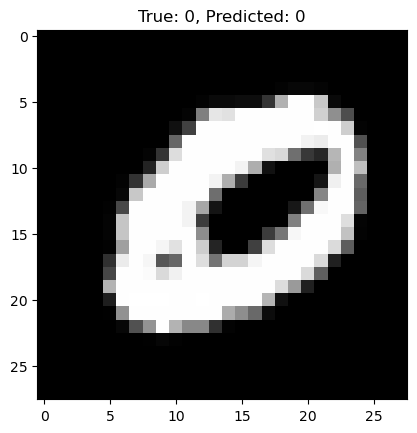

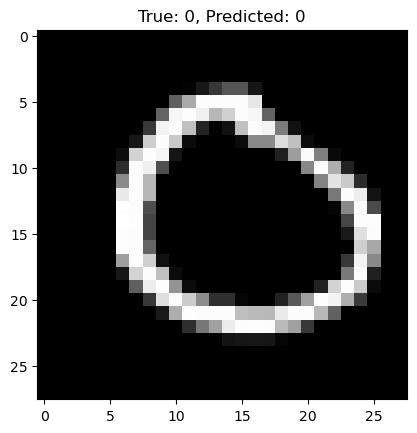

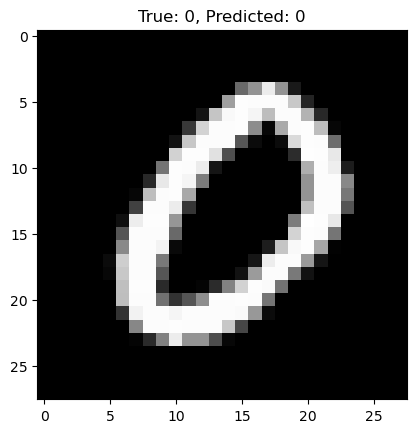

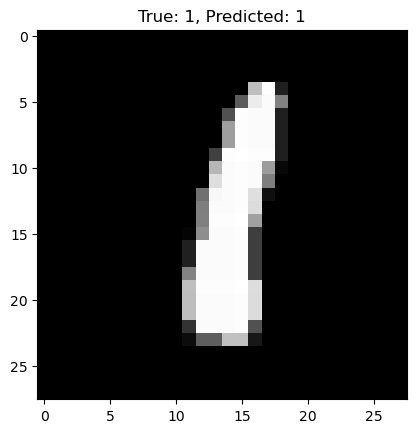

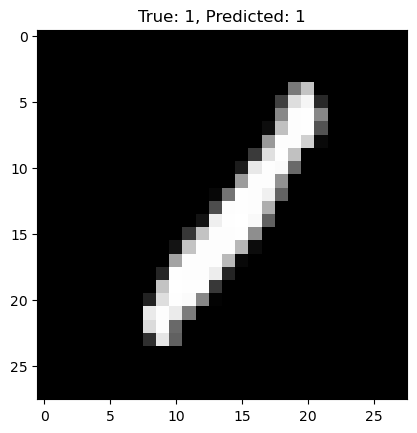

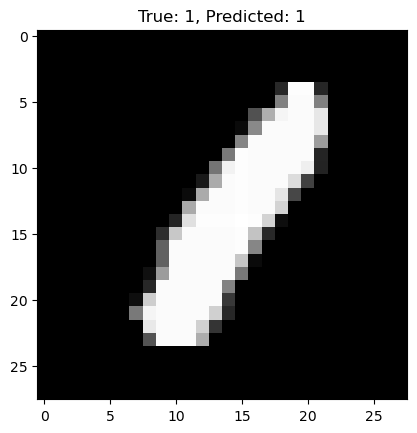

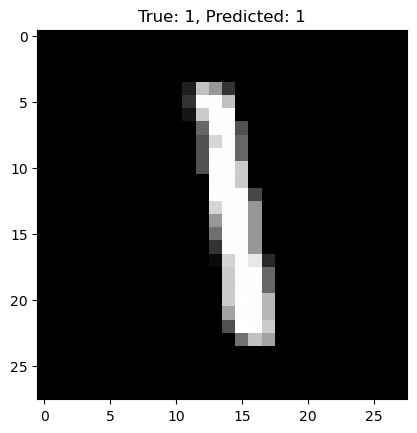

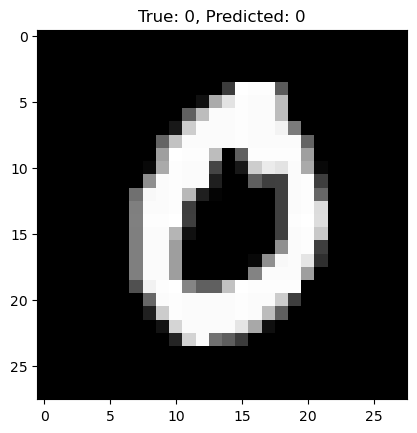

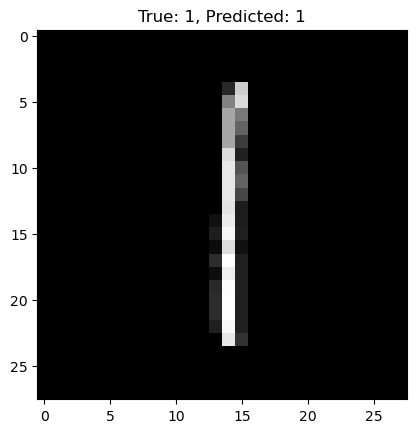

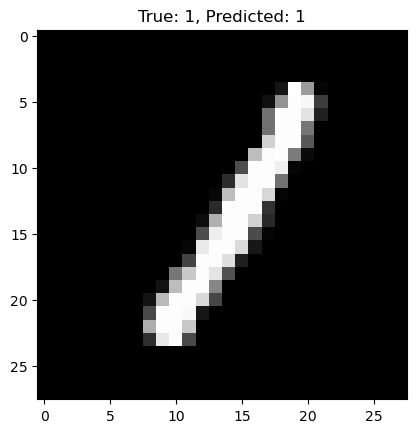

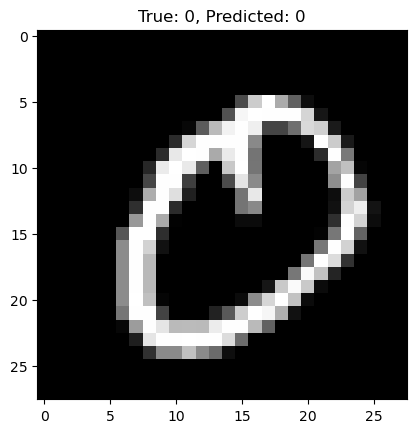

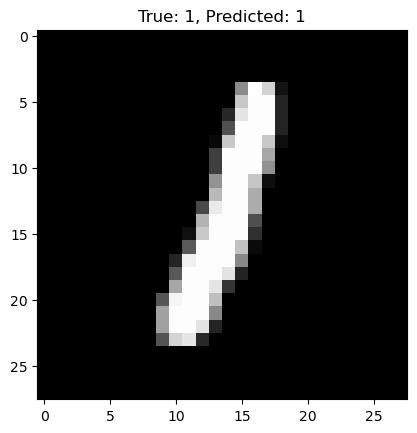

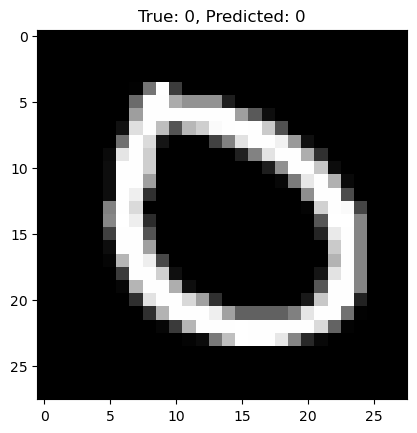

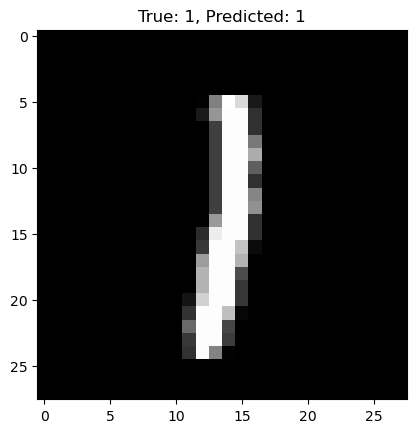

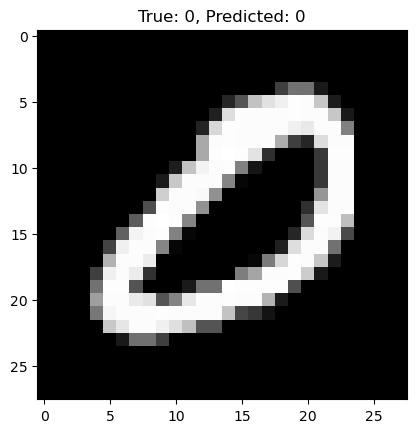

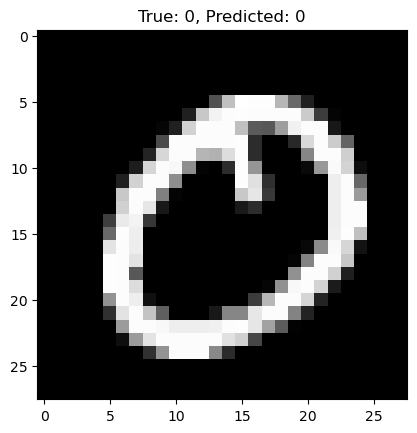

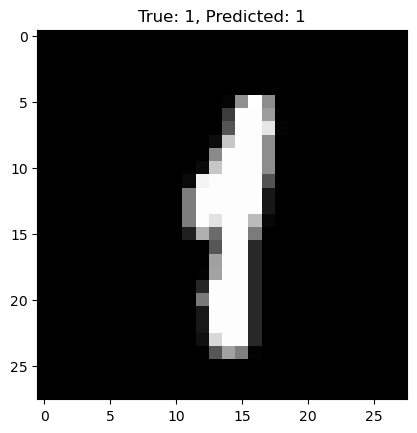

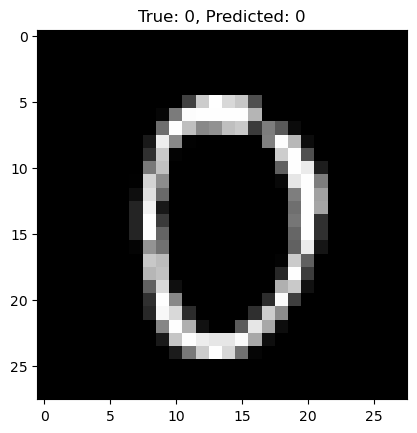

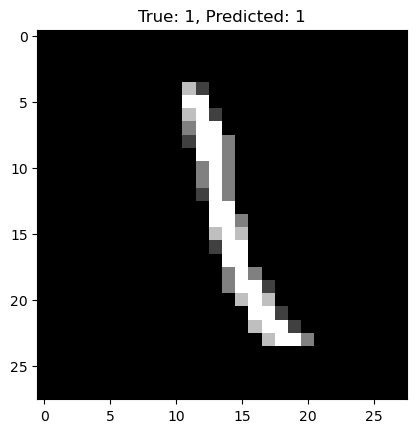

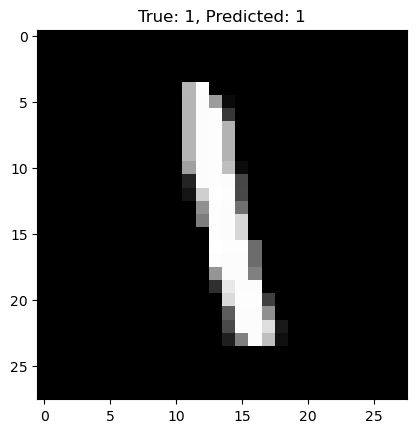

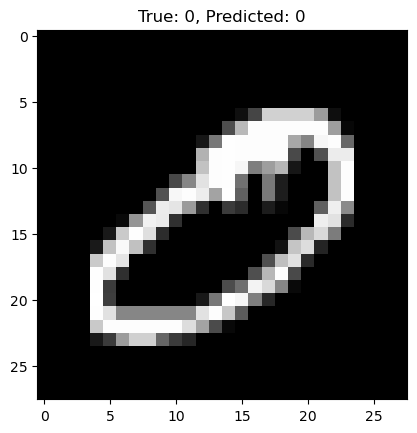

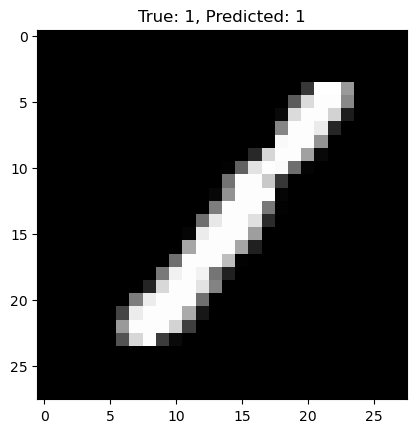

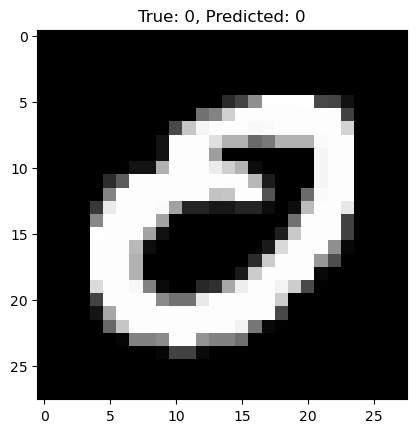

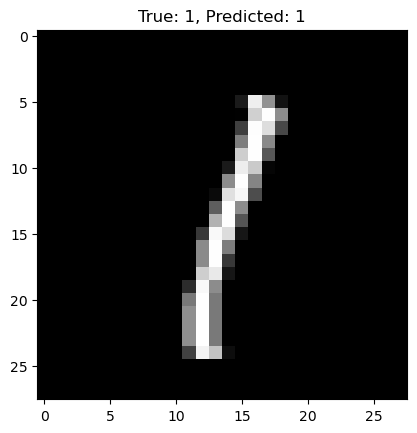

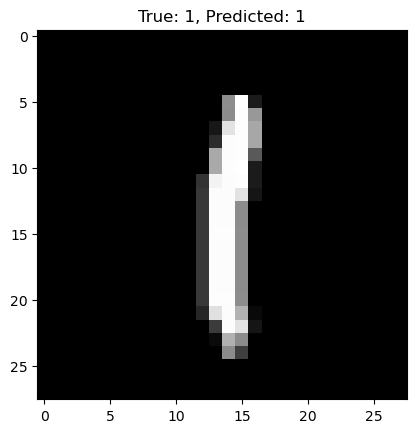

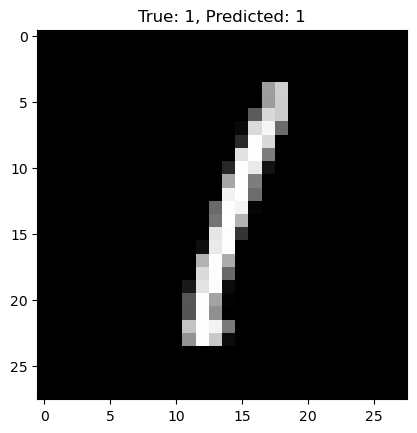

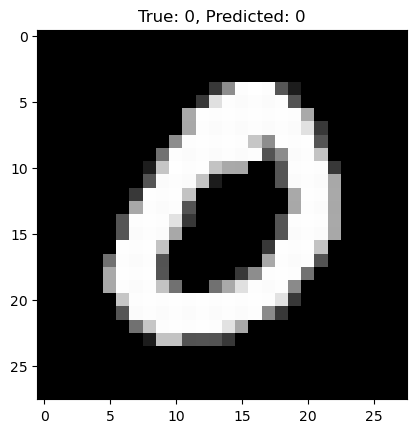

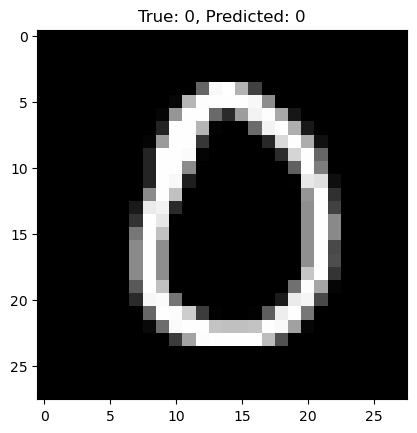

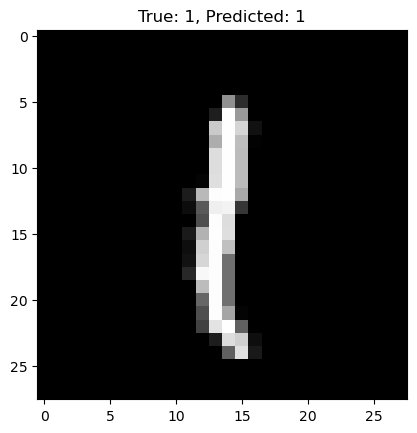

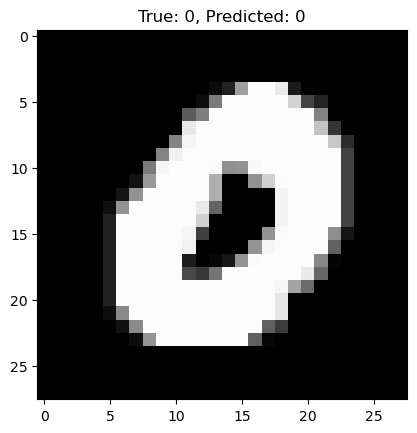

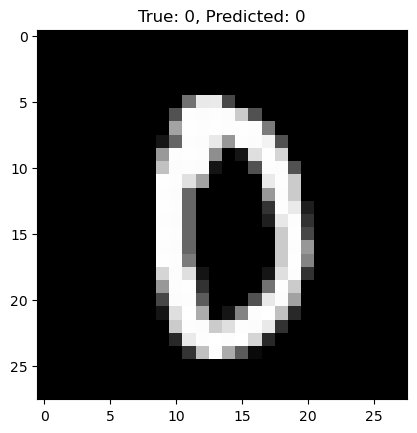

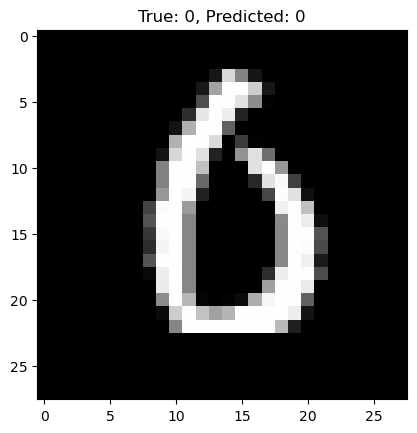

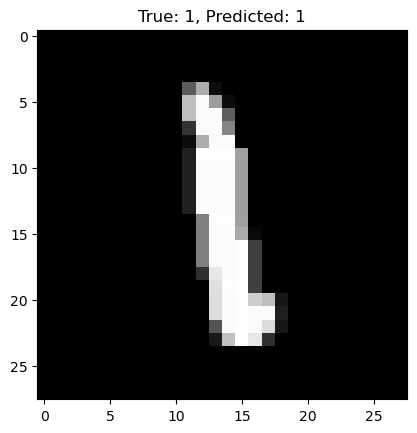

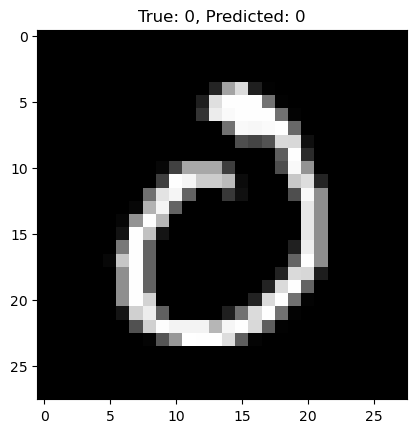

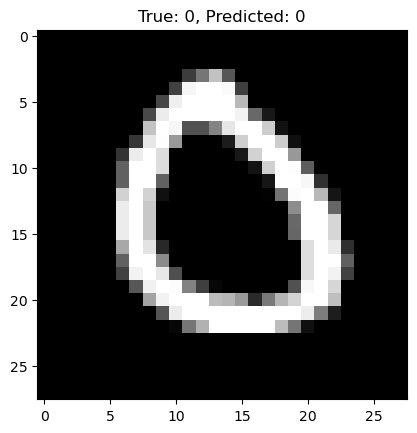

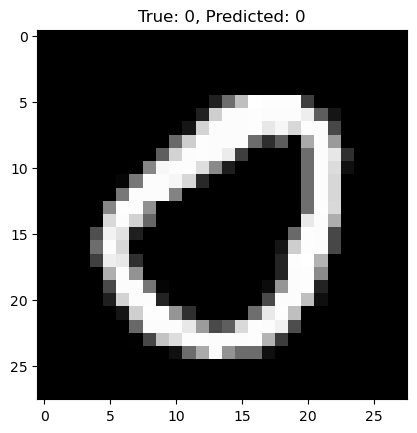

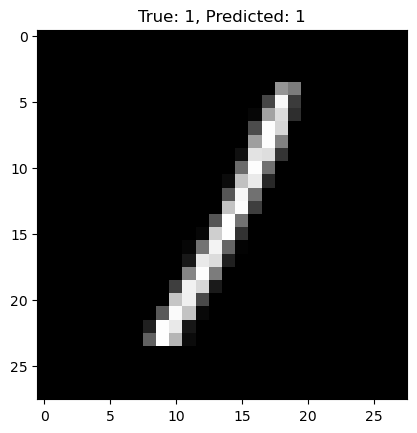

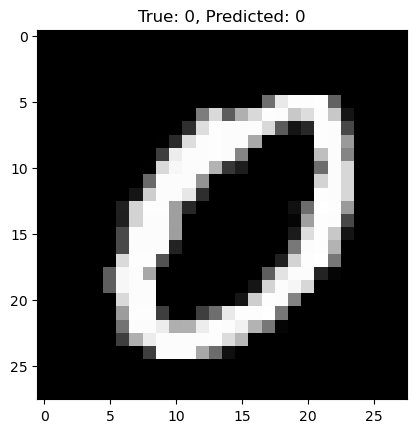

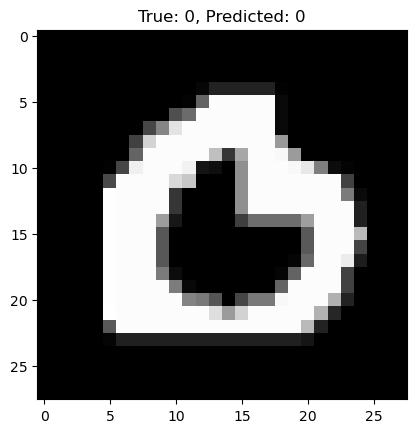

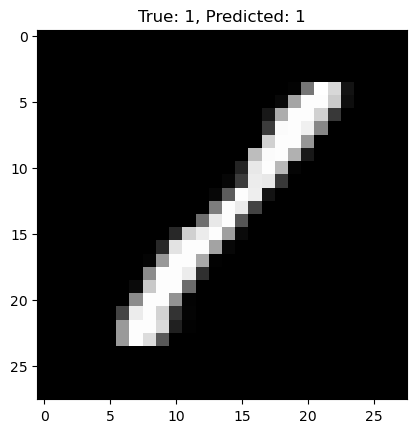

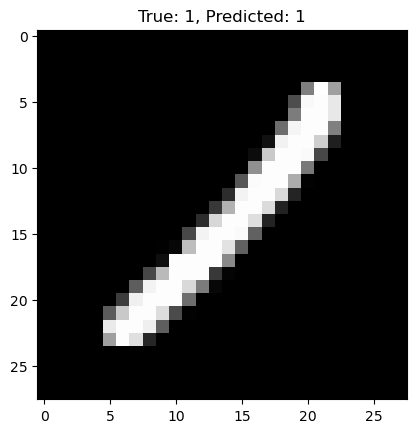

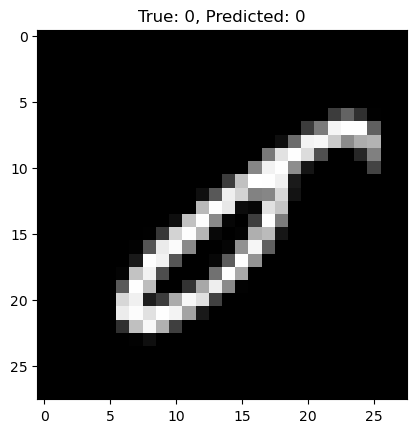

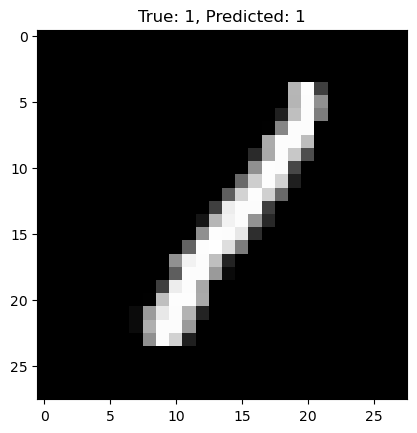

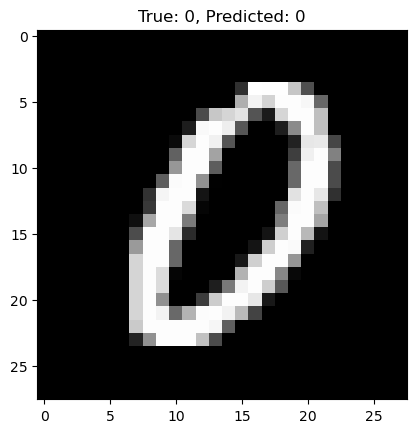

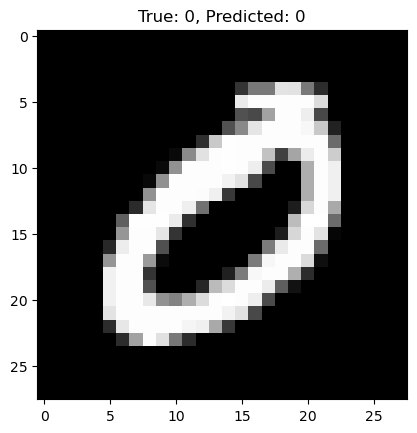

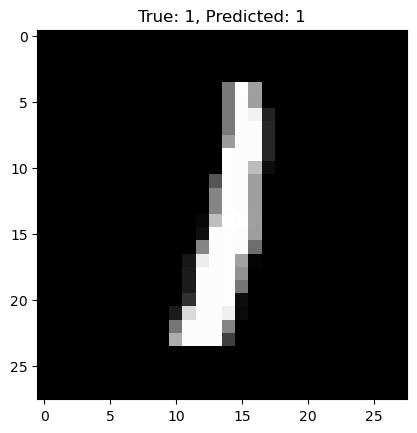

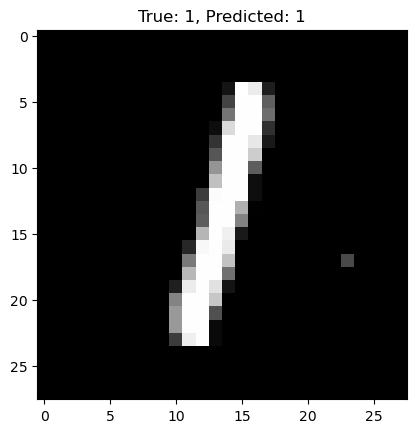

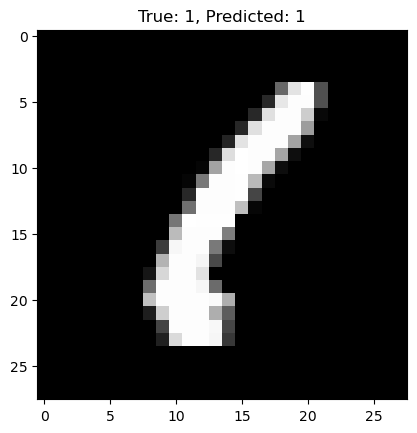

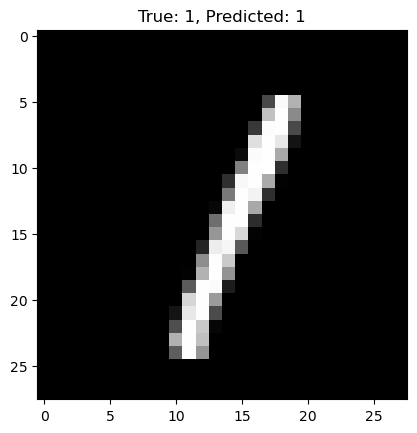

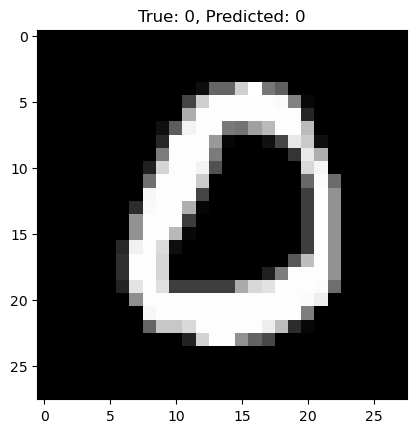

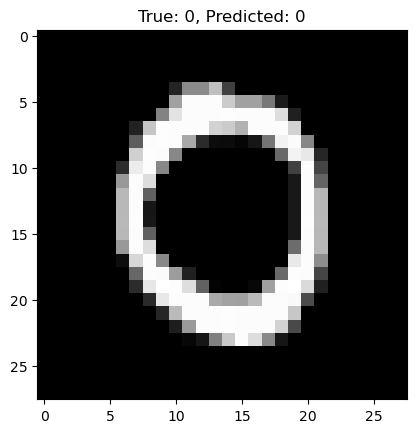

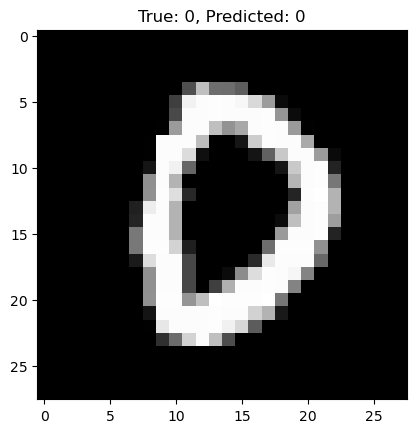

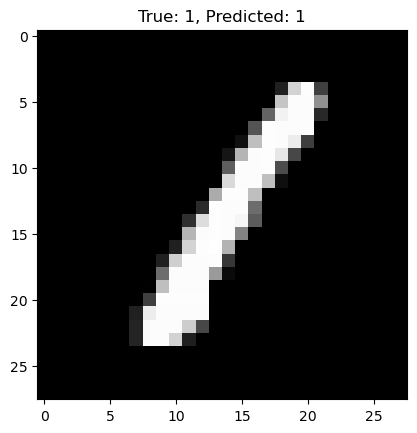

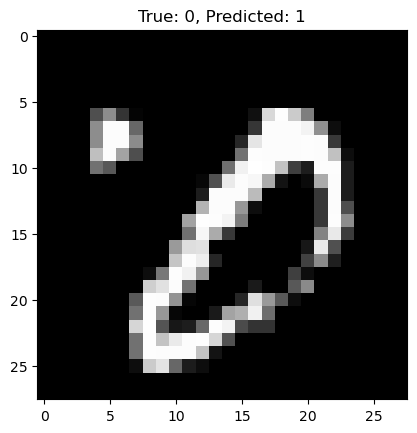

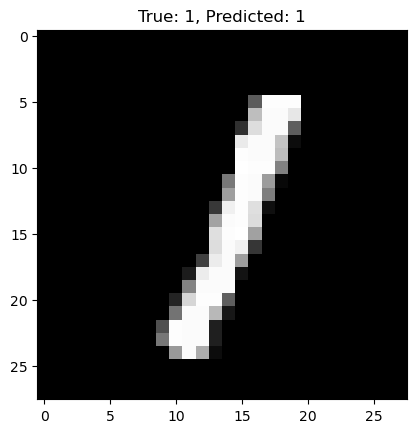

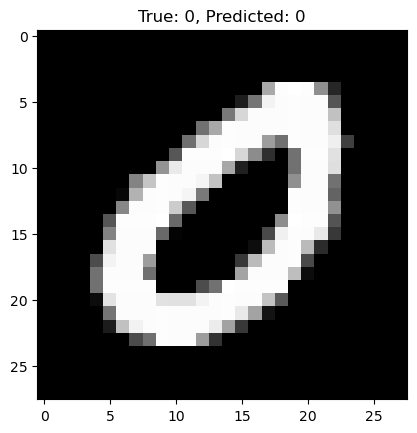

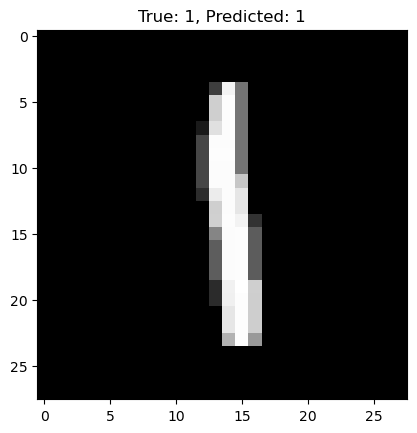

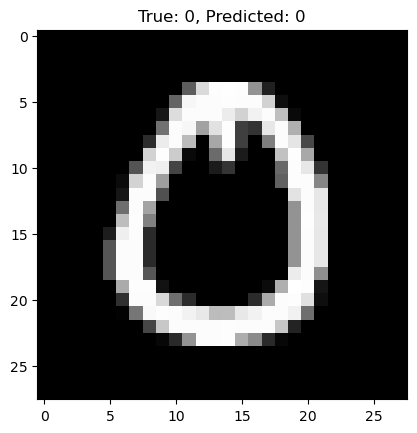

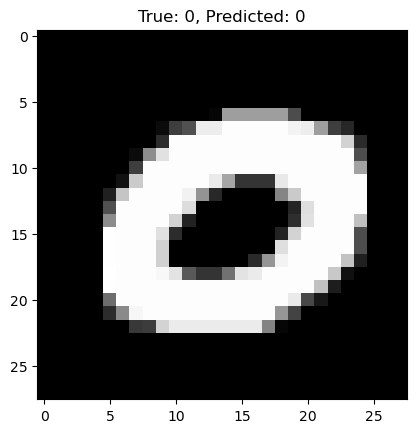

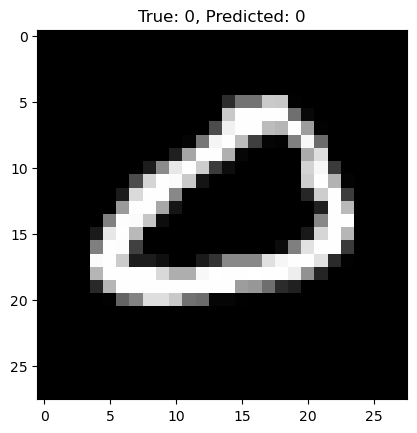

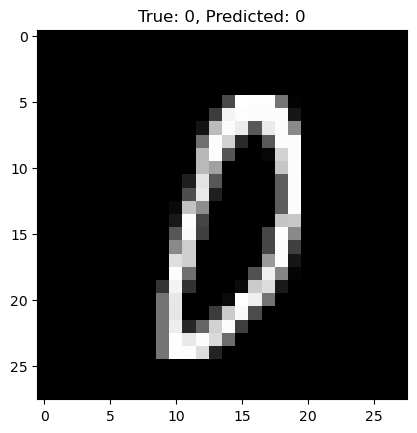

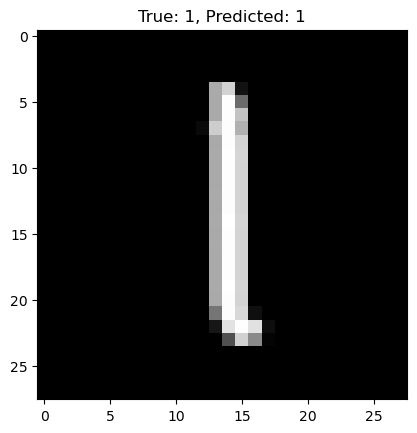

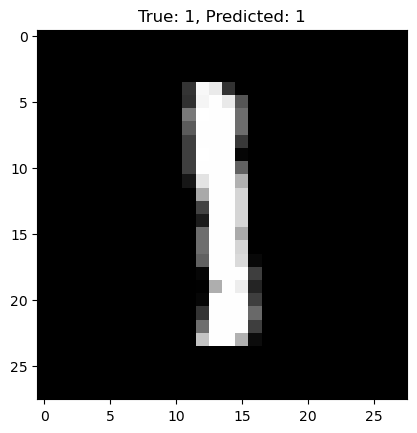

In [13]:
import matplotlib.pyplot as plt

for i in range(100):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[i]}, Predicted: {y_pred[i]}")
    plt.show()